# Biprobability plots

The neutrino probability $P(\nu_\alpha \to \nu_\beta)$ against the antineutrino one $P(\bar\nu_\alpha \to \bar\nu_\beta)$, traced as the CP phase runs over its range.

The area enclosed is the CP violation an experiment is trying to measure.

In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

# Mag(nu)s is imported as an installed package -- from the repository root,
# 'pip install -e .' (add [plot] for magnus.plotting). No sys.path juggling.
import magnus.oscprob as oscprob
import magnus.oscprobstd as oscprobstd
import magnus.hamiltonians as hamiltonians
import magnus.matter as matter
import magnus.earth as earth
import magnus.globaldefs as gd
import magnus.plotting as plotting

Biprobability plots show how neutrino vs. anti-neutrino oscillation probabilities change as a function of the CP-violation phase, $\delta_{\rm CP}$.  This is typically done for neutrino propagation in matter, representing the setup of long-baseline neutrino oscillations in which $\delta_{\rm CP}$ is expected to be measured.  Biprobability plots are useful to illustrate the separation between neutrino and anti-neutrino oscillation probabilities from which this measurement is performed.

Sometimes, biprobability plots include new-physics effects that affect the probabilities, in order to show how their presence could cloud the measurement of $\delta_{\rm CP}$.  In this notebook, we use Mag$\nu$s to produce biprobability plots only under standard $3\nu$ oscillations; for biprobability plots including sterile neutrinos and non-standard interactions, see notebooks `07_magnus_bsm_sterile_nu.ipynb` and `08_magnus_bsm_nsi.ipynb`, respectively.

## Plotting function

First, let's define a general-purpose plotting function to produce biprobability plots, given precomputed neutrino and anti-neutrino oscillation probabilities:

In [2]:
def make_plot_biprobability(prob_nu_arr, prob_nubar_arr, ls, lc, lw,
                            label_prob_nu, label_prob_nubar, points_sel_arr=None,
                            annotations=None, xaxis_major_locator=None,
                            xaxis_minor_locator=None, yaxis_major_locator=None,
                            yaxis_minor_locator=None, leg_fontsize=16, leg_loc=None,
                            leg_ncol=1, xlim=None, ylim=None, save_fig=False,
                            fig_filename=None, fig_format='pdf'):
    """Draw a bi-probability plane via magnus.plotting.

    The stored curves carry the delta_CP value in column 0 and the probability
    in column 1, so only column 1 is plotted. Each marker entry is
    [label, marker, filled, [x, y]] and is translated into the module's form.
    """
    def spacing(loc):
        # the notebook passes MultipleLocator objects; the module takes the step
        return None if loc is None else float(np.diff(loc.tick_values(0.0, 1.0))[0])

    markers = None
    if points_sel_arr is not None:
        # points_sel_arr[i] holds curve i's marked phases, each as
        # [label, marker, filled, [x, y]] -- coordinates, not indices, because the
        # marked phases were computed separately from the curve. Only the first
        # curve's markers carry labels, so the legend names each phase once.
        markers = [dict(xy=(p[3][0], p[3][1]), marker=p[1],
                        filled=(p[2] is True), curve=i,
                        **({'label': p[0]} if i == 0 else {}))
                   for i, points_sel in enumerate(points_sel_arr)
                   for p in points_sel]

    fig, ax = plotting.plot_biprobability(
        [np.asarray(c)[:, 1] for c in prob_nu_arr],
        [np.asarray(c)[:, 1] for c in prob_nubar_arr],
        curve_kw=[dict(color=lc[i], ls=ls[i], lw=lw[i])
                  for i in range(len(prob_nu_arr))],
        markers=markers,
        xlabel=label_prob_nu, ylabel=label_prob_nubar,
        xlim=xlim, ylim=ylim,
        xmajor=spacing(xaxis_major_locator), xminor=spacing(xaxis_minor_locator),
        ymajor=spacing(yaxis_major_locator), yminor=spacing(yaxis_minor_locator),
        annotations=[dict(text=a['text'], xy=a['xy'], color=a['color'],
                          fontsize=a['fontsize'], ha=a['ha'])
                     for a in (annotations or [])],
        legend_loc=leg_loc,
        legend_kw=dict(fontsize=leg_fontsize, ncol=leg_ncol, framealpha=1.0),
        savefig=(fig_filename + '.' + fig_format) if save_fig else None,
        savefig_kw=dict(transparent=False, bbox_inches='tight', dpi=300))
    return fig, ax

## In vacuum

Let's start with the case of propagation in vacuum, comparing the plots obtained under normal mass ordering (NO) and under inverted mass ordering (IO).  In each case, we fix the mixing parameters to their best-fit values from the NuFit 6.0 global fit to oscillation data, which are stored in the `globaldefs` module of Mag$\nu$s.

In [3]:
# Mixing parameters (predefined examples from globaldefs; can change them to anything else)
s12_NO = gd.S12_NO_BF_NUFIT_6_0 # [adim]
s23_NO = gd.S23_NO_BF_NUFIT_6_0 # [adim]
s13_NO = gd.S13_NO_BF_NUFIT_6_0 # [adim]
dCP_NO = gd.DCP_NO_BF_NUFIT_6_0 # [adim]
D21_NO = gd.D21_NO_BF_NUFIT_6_0 # [eV^2]
D31_NO = gd.D31_NO_BF_NUFIT_6_0 # [eV^2]
s12_IO = gd.S12_IO_BF_NUFIT_6_0 # [adim]
s23_IO = gd.S23_IO_BF_NUFIT_6_0 # [adim]
s13_IO = gd.S13_IO_BF_NUFIT_6_0 # [adim]
dCP_IO = gd.DCP_IO_BF_NUFIT_6_0 # [adim]
D21_IO = gd.D21_IO_BF_NUFIT_6_0 # [eV^2]
D31_IO = gd.D31_IO_BF_NUFIT_6_0 # [eV^2]

In [4]:
# Pick the baseline and energy of T2K
baseline = 810 # [km]
energy = 2*gd.UNIT_MEV # [eV]

# Values of the delta_CP phase at which to compute the probabilities
dCP_npts = 100
dCP_arr = np.linspace(-np.pi, np.pi, dCP_npts)

# We will compute the appearance probabilities, i.e., nu_mu --> nu_e and nu_mu-bar --> nu_e-bar
nu_i, nu_f = gd.NUMU, gd.NUE

# Hamiltonian in vacuum for neutrinos
def H_nu(s12, s23, s13, dCP, D21, D31):
    return hamiltonians.hamiltonian_3nu_vacuum(energy, s12, s23, s13, dCP, D21, D31, nubar=False, compute_matrix_multiplication=False)

# Hamiltonian in vacuum for anti-neutrinos
def H_nubar(s12, s23, s13, dCP, D21, D31):
    return hamiltonians.hamiltonian_3nu_vacuum(energy, s12, s23, s13, dCP, D21, D31, nubar=True, compute_matrix_multiplication=False)

# Generate the neutrino and anti-neutrino oscillation probabilities for many different values of dCP
# osc_prob returns a 3x3 NumPy array with the probabilities: [[Pee, Pem, Pet], [Pme, Pmm, Pmt], [Pte, Ptm, Ptt]]
# nu_mu --> nu_e, normal ordering
prob_nu_NO = np.array([[dCP/np.pi, oscprob.osc_prob(lambda l: H_nu(s12_NO, s23_NO, s13_NO, dCP, D21_NO, D31_NO), 
                                                    0.0, baseline*gd.CONV_KM_TO_INV_EV, 
                                                    n_slabs=1, n_tpts_per_slab=2, magnus_exp_order=1,
                                                    integration_method='simpson', n_jobs=1)[nu_i][nu_f]] for dCP in dCP_arr])
# nu_mu-bar --> nu_e-bar, normal ordering
prob_nubar_NO = np.array([[dCP/np.pi, oscprob.osc_prob(lambda l: H_nubar(s12_NO, s23_NO, s13_NO, dCP, D21_NO, D31_NO),
                                                       0.0, baseline*gd.CONV_KM_TO_INV_EV, 
                                                       n_slabs=1, n_tpts_per_slab=2, magnus_exp_order=1,
                                                       integration_method='simpson', n_jobs=1)[nu_i][nu_f]] for dCP in dCP_arr])
# nu_mu --> nu_e, inverted ordering
prob_nu_IO = np.array([[dCP/np.pi, oscprob.osc_prob(lambda l: H_nu(s12_IO, s23_IO, s13_IO, dCP, D21_IO, D31_IO), 
                                                    0.0, baseline*gd.CONV_KM_TO_INV_EV, 
                                                    n_slabs=1, n_tpts_per_slab=2, magnus_exp_order=1,
                                                    integration_method='simpson', n_jobs=1)[nu_i][nu_f]] for dCP in dCP_arr])
# nu_mu-bar --> nu_e-bar, inverted ordering
prob_nubar_IO = np.array([[dCP/np.pi, oscprob.osc_prob(lambda l: H_nubar(s12_IO, s23_IO, s13_IO, dCP, D21_IO, D31_IO),
                                                       0.0, baseline*gd.CONV_KM_TO_INV_EV, 
                                                       n_slabs=1, n_tpts_per_slab=2, magnus_exp_order=1,
                                                       integration_method='simpson', n_jobs=1)[nu_i][nu_f]] for dCP in dCP_arr])

# Points for selected values of dCP
dCP_sel = [-np.pi, -0.75*np.pi, -0.5*np.pi, -0.25*np.pi, 0, 0.25*np.pi, 0.5*np.pi, 0.75*np.pi]
dCP_label_sel = [r'$-\pi, \pi$', r'$-3\pi/4$', r'$-\pi/2$', r'$-\pi/4$', r'$0$', r'$\pi/4$', r'$\pi/2$', r'$3\pi/4$', 'NuFit 6.0']
markers = ['o', 'v', 's', 'p', '*', 'p', 's', 'v', '^']
filled = [True, True, True, True, True, False, False, False, True]
prob_nu_NO_sel = np.array([[dCP/np.pi, oscprob.osc_prob(lambda l: H_nu(s12_NO, s23_NO, s13_NO, dCP, D21_NO, D31_NO), 
                                                        0.0, baseline*gd.CONV_KM_TO_INV_EV, 
                                                        n_slabs=1, n_tpts_per_slab=2, magnus_exp_order=1,
                                                        integration_method='simpson', n_jobs=1)[nu_i][nu_f]] 
                           for dCP in dCP_sel+[gd.DCP_NO_BF_NUFIT_6_0]])
prob_nubar_NO_sel = np.array([[dCP/np.pi, oscprob.osc_prob(lambda l: H_nubar(s12_NO, s23_NO, s13_NO, dCP, D21_NO, D31_NO), 
                                                           0.0, baseline*gd.CONV_KM_TO_INV_EV, 
                                                           n_slabs=1, n_tpts_per_slab=2, magnus_exp_order=1,
                                                           integration_method='simpson', n_jobs=1)[nu_i][nu_f]]
                              for dCP in dCP_sel+[gd.DCP_NO_BF_NUFIT_6_0]])
prob_nu_IO_sel = np.array([[dCP/np.pi, oscprob.osc_prob(lambda l: H_nu(s12_IO, s23_IO, s13_IO, dCP, D21_IO, D31_IO), 
                                                        0.0, baseline*gd.CONV_KM_TO_INV_EV, 
                                                        n_slabs=1, n_tpts_per_slab=2, magnus_exp_order=1,
                                                        integration_method='simpson', n_jobs=1)[nu_i][nu_f]]
                           for dCP in dCP_sel+[gd.DCP_IO_BF_NUFIT_6_0]])
prob_nubar_IO_sel = np.array([[dCP/np.pi, oscprob.osc_prob(lambda l: H_nubar(s12_IO, s23_IO, s13_IO, dCP, D21_IO, D31_IO), 
                                                           0.0, baseline*gd.CONV_KM_TO_INV_EV, 
                                                           n_slabs=1, n_tpts_per_slab=2, magnus_exp_order=1,
                                                           integration_method='simpson', n_jobs=1)[nu_i][nu_f]]
                              for dCP in dCP_sel+[gd.DCP_IO_BF_NUFIT_6_0]])
points_NO_sel = [[dCP_label_sel[i], markers[i], filled[i], [prob_nu_NO_sel[i][1], prob_nubar_NO_sel[i][1]]] for i in range(len(dCP_sel)+1)]
points_IO_sel = [[dCP_label_sel[i], markers[i], filled[i], [prob_nu_IO_sel[i][1], prob_nubar_IO_sel[i][1]]] for i in range(len(dCP_sel)+1)]

(<Figure size 900x900 with 1 Axes>,
 <Axes: xlabel='Neutrino probability, $P_{\\nu_\\mu \\to \\nu_e}$', ylabel='Anti-neutrino probability, $P_{\\bar{\\nu}_\\mu \\to \\bar{\\nu}_e}$'>)

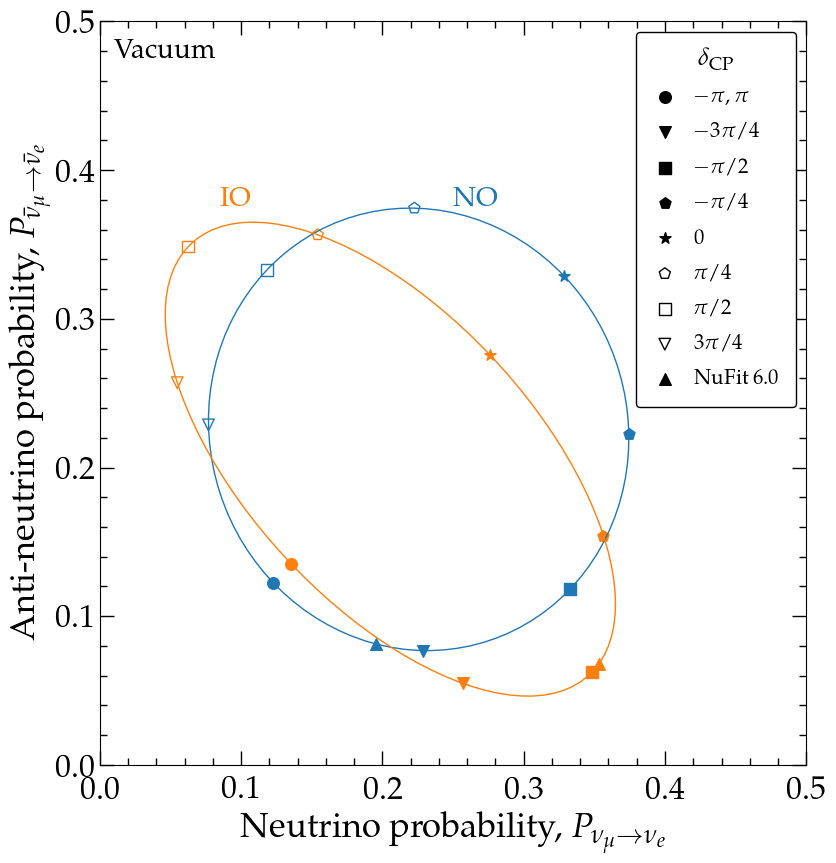

In [5]:
make_plot_biprobability([prob_nu_NO, prob_nu_IO], 
                        [prob_nubar_NO, prob_nubar_IO],
                        lc=['C0', 'C1'], ls=['-', '-'], lw=[1.0, 1.0],
                        points_sel_arr=[points_NO_sel, points_IO_sel],
                        label_prob_nu=r'Neutrino probability, $P_{\nu_\mu \to \nu_e}$', 
                        label_prob_nubar=r'Anti-neutrino probability, $P_{\bar{\nu}_\mu \to \bar{\nu}_e}$',
                        annotations=[
                            {'text': 'Vacuum', 'xy': (0.02,0.95), 'color': 'k', 'fontsize': 20, 'ha': 'left'},
                            {'text': 'NO', 'xy': (0.5,0.75), 'color': 'C0', 'fontsize': 20, 'ha': 'left'},
                            {'text': 'IO', 'xy': (0.17,0.75), 'color': 'C1', 'fontsize': 20, 'ha': 'left'}
                        ], 
                        xaxis_major_locator=mpl.ticker.MultipleLocator(base=0.10),
                        xaxis_minor_locator=mpl.ticker.MultipleLocator(base=0.02),
                        yaxis_major_locator=mpl.ticker.MultipleLocator(base=0.10),
                        yaxis_minor_locator=mpl.ticker.MultipleLocator(base=0.02),
                        leg_fontsize=15, leg_loc='upper right', leg_ncol=1, xlim=[0,0.50], ylim=[0,0.50], save_fig=False)

To validate this result, which was produced using the Mag$\nu$s expansion (albeit, to first order only, since for propoagation in vacuum this is enough), we compute the biprobability using the standard $3\nu$ oscillation probability instead.

In [6]:
# Generate the neutrino and anti-neutrino oscillation probabilities for many different values of dCP
# osc_prob_3nu_vacuum_std returns a 3x3 NumPy array with the probabilities: [[Pee, Pem, Pet], [Pme, Pmm, Pmt], [Pte, Ptm, Ptt]]
prob_nu_std_NO = np.array([[dCP/np.pi, oscprobstd.osc_prob_3nu_vacuum_std(hamiltonians.pmns_mixing_matrix(s12_NO, s23_NO, s13_NO, dCP),
                                                                          D21_NO, D31_NO, energy, baseline*gd.CONV_KM_TO_INV_EV,
                                                                          nubar=False)[nu_i][nu_f]] for dCP in dCP_arr])
# nu_mu-bar --> nu_e-bar, normal ordering
prob_nubar_std_NO = np.array([[dCP/np.pi, oscprobstd.osc_prob_3nu_vacuum_std(hamiltonians.pmns_mixing_matrix(s12_NO, s23_NO, s13_NO, dCP),
                                                                             D21_NO, D31_NO, energy, baseline*gd.CONV_KM_TO_INV_EV,
                                                                             nubar=True)[nu_i][nu_f]] for dCP in dCP_arr])
# nu_mu --> nu_e, inverted ordering
prob_nu_std_IO = np.array([[dCP/np.pi, oscprobstd.osc_prob_3nu_vacuum_std(hamiltonians.pmns_mixing_matrix(s12_IO, s23_IO, s13_IO, dCP),
                                                                          D21_IO, D31_IO, energy, baseline*gd.CONV_KM_TO_INV_EV,
                                                                          nubar=False)[nu_i][nu_f]] for dCP in dCP_arr])
# nu_mu-bar --> nu_e-bar, inverted ordering
prob_nubar_std_IO = np.array([[dCP/np.pi, oscprobstd.osc_prob_3nu_vacuum_std(hamiltonians.pmns_mixing_matrix(s12_IO, s23_IO, s13_IO, dCP),
                                                                             D21_IO, D31_IO, energy, baseline*gd.CONV_KM_TO_INV_EV,
                                                                             nubar=True)[nu_i][nu_f]] for dCP in dCP_arr])

# Points for selected values of dCP
dCP_sel = [-np.pi, -0.75*np.pi, -0.5*np.pi, -0.25*np.pi, 0, 0.25*np.pi, 0.5*np.pi, 0.75*np.pi]
dCP_label_sel = [r'$-\pi, \pi$', r'$-3\pi/4$', r'$-\pi/2$', r'$-\pi/4$', r'$0$', r'$\pi/4$', r'$\pi/2$', r'$3\pi/4$', 'NuFit 6.0']
markers = ['o', 'v', 's', 'p', '*', 'p', 's', 'v', '^']
filled = [True, True, True, True, True, False, False, False, True]
prob_nu_std_NO_sel = np.array([[dCP/np.pi, oscprobstd.osc_prob_3nu_vacuum_std(
    hamiltonians.pmns_mixing_matrix(s12_NO, s23_NO, s13_NO, dCP), D21_NO, D31_NO, energy, baseline*gd.CONV_KM_TO_INV_EV, 
    nubar=False)[nu_i][nu_f]] for dCP in dCP_sel+[gd.DCP_NO_BF_NUFIT_6_0]])
prob_nubar_std_NO_sel = np.array([[dCP/np.pi, oscprobstd.osc_prob_3nu_vacuum_std(
    hamiltonians.pmns_mixing_matrix(s12_NO, s23_NO, s13_NO, dCP), D21_NO, D31_NO, energy, baseline*gd.CONV_KM_TO_INV_EV, 
    nubar=True)[nu_i][nu_f]] for dCP in dCP_sel+[gd.DCP_NO_BF_NUFIT_6_0]])
prob_nu_std_IO_sel = np.array([[dCP/np.pi, oscprobstd.osc_prob_3nu_vacuum_std(
    hamiltonians.pmns_mixing_matrix(s12_IO, s23_IO, s13_IO, dCP), D21_NO, D31_NO, energy, baseline*gd.CONV_KM_TO_INV_EV, 
    nubar=False)[nu_i][nu_f]] for dCP in dCP_sel+[gd.DCP_NO_BF_NUFIT_6_0]])
prob_nubar_std_IO_sel = np.array([[dCP/np.pi, oscprobstd.osc_prob_3nu_vacuum_std(
    hamiltonians.pmns_mixing_matrix(s12_IO, s23_IO, s13_IO, dCP), D21_NO, D31_NO, energy, baseline*gd.CONV_KM_TO_INV_EV, 
    nubar=True)[nu_i][nu_f]] for dCP in dCP_sel+[gd.DCP_NO_BF_NUFIT_6_0]])
points_std_NO_sel = [[dCP_label_sel[i], markers[i], filled[i], [prob_nu_std_NO_sel[i][1], prob_nubar_std_NO_sel[i][1]]] 
                     for i in range(len(dCP_sel)+1)]
points_std_IO_sel = [[dCP_label_sel[i], markers[i], filled[i], [prob_nu_std_IO_sel[i][1], prob_nubar_std_IO_sel[i][1]]] 
                     for i in range(len(dCP_sel)+1)]

(<Figure size 900x900 with 1 Axes>,
 <Axes: xlabel='Neutrino probability, $P_{\\nu_\\mu \\to \\nu_e}$', ylabel='Anti-neutrino probability, $P_{\\bar{\\nu}_\\mu \\to \\bar{\\nu}_e}$'>)

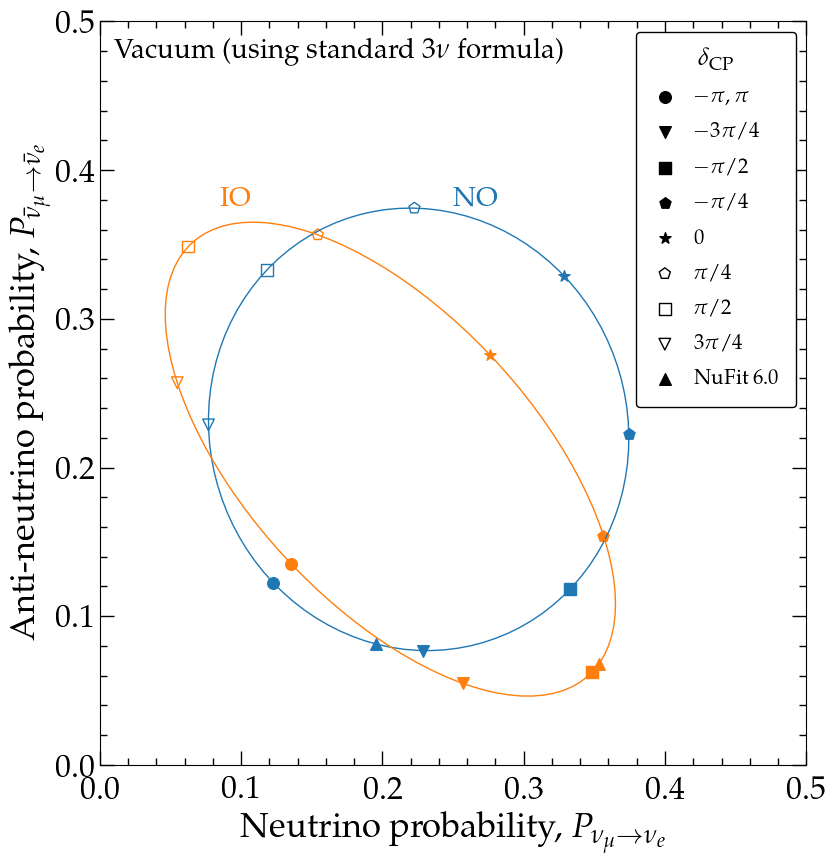

In [7]:
make_plot_biprobability([prob_nu_std_NO, prob_nu_std_IO], 
                        [prob_nubar_std_NO, prob_nubar_std_IO],
                        lc=['C0', 'C1'], ls=['-', '-'], lw=[1.0, 1.0],
                        points_sel_arr=[points_NO_sel, points_IO_sel],
                        label_prob_nu=r'Neutrino probability, $P_{\nu_\mu \to \nu_e}$', 
                        label_prob_nubar=r'Anti-neutrino probability, $P_{\bar{\nu}_\mu \to \bar{\nu}_e}$',
                        annotations=[
                            {'text': r'Vacuum (using standard $3\nu$ formula)', 'xy': (0.02,0.95), 'color': 'k', 'fontsize': 20, 'ha': 'left'},
                            {'text': 'NO', 'xy': (0.5,0.75), 'color': 'C0', 'fontsize': 20, 'ha': 'left'},
                            {'text': 'IO', 'xy': (0.17,0.75), 'color': 'C1', 'fontsize': 20, 'ha': 'left'}
                        ], 
                        xaxis_major_locator=mpl.ticker.MultipleLocator(base=0.10),
                        xaxis_minor_locator=mpl.ticker.MultipleLocator(base=0.02),
                        yaxis_major_locator=mpl.ticker.MultipleLocator(base=0.10),
                        yaxis_minor_locator=mpl.ticker.MultipleLocator(base=0.02),
                        leg_fontsize=15, leg_loc='upper right', leg_ncol=1, xlim=[0,0.50], ylim=[0,0.50], save_fig=False)

And this biprobability plot is, as expected, identical as the one produced using the Magnus expansion.

## In matter, long-baseline experiments (constant density, Earth's crust)

Now let's generate the biprobability plot in matter, for the NO$\nu$A, T2K, and DUNE long-baseline setups.  Compare the plots below to the ones shown in Fig. 7 of arXiv:1307.3248.

In [8]:
# ====== NOvA ======

# Pick the baseline and energy of NOvA
baseline = 810 # [km]
energy = 2*gd.UNIT_GEV # [eV]

# Values of the delta_CP phase at which to compute the probabilities
dCP_npts = 100
dCP_arr = np.linspace(-np.pi, np.pi, dCP_npts)

# We will compute the appearance probabilities, i.e., nu_mu --> nu_e and nu_mu-bar --> nu_e-bar
nu_i, nu_f = gd.NUMU, gd.NUE

# Coherent matter potential in matter
rho = 3.0 # Average matter density in the Earth's crus [g cm^{-3}]
num_density_e = matter.num_density_e_func(l=0.0, density_matter_func=lambda l: rho, electron_fraction=0.5, density_matter_is_in_g_per_cm3=True) # Electron number density [eV^3]
VCC = matter.VCC_func(l=0.0, num_density_e_func=lambda l: num_density_e) # Coherent forward potential, VCC [eV]
# Note: we could have directly used VCC = gd.NUM_DENSITY_E_EARTH_CRUST

# Hamiltonian in matter
H_matt = hamiltonians.hamiltonian_3nu_matter(VCC)

# Hamiltonian for neutrinos (the matter potential is added)
def H_nu(s12, s23, s13, dCP, D21, D31):
    return hamiltonians.hamiltonian_3nu_vacuum(energy, s12, s23, s13, dCP, D21, D31, nubar=False, compute_matrix_multiplication=False) \
    + H_matt

# Hamiltonian for anti-neutrinos (the matter potential is subtracted)
def H_nubar(s12, s23, s13, dCP, D21, D31):
    return hamiltonians.hamiltonian_3nu_vacuum(energy, s12, s23, s13, dCP, D21, D31, nubar=True, compute_matrix_multiplication=False) \
    - H_matt

# Generate the neutrino and anti-neutrino oscillation probabilities for many different values of dCP
# osc_prob returns a 3x3 NumPy array with the probabilities: [[Pee, Pem, Pet], [Pme, Pmm, Pmt], [Pte, Ptm, Ptt]]
# nu_mu --> nu_e, normal ordering
prob_nu_NO = np.array([[dCP/np.pi, oscprob.osc_prob(lambda l: H_nu(s12_NO, s23_NO, s13_NO, dCP, D21_NO, D31_NO), 
                                                    0.0, baseline*gd.CONV_KM_TO_INV_EV, 
                                                    n_slabs=1, n_tpts_per_slab=2, magnus_exp_order=1,
                                                    integration_method='simpson', n_jobs=1)[nu_i][nu_f]] for dCP in dCP_arr])
# nu_mu-bar --> nu_e-bar, normal ordering
prob_nubar_NO = np.array([[dCP/np.pi, oscprob.osc_prob(lambda l: H_nubar(s12_NO, s23_NO, s13_NO, dCP, D21_NO, D31_NO),
                                                       0.0, baseline*gd.CONV_KM_TO_INV_EV, 
                                                       n_slabs=1, n_tpts_per_slab=2, magnus_exp_order=1,
                                                       integration_method='simpson', n_jobs=1)[nu_i][nu_f]] for dCP in dCP_arr])
# nu_mu --> nu_e, inverted ordering
prob_nu_IO = np.array([[dCP/np.pi, oscprob.osc_prob(lambda l: H_nu(s12_IO, s23_IO, s13_IO, dCP, D21_IO, D31_IO), 
                                                    0.0, baseline*gd.CONV_KM_TO_INV_EV, 
                                                    n_slabs=1, n_tpts_per_slab=2, magnus_exp_order=1,
                                                    integration_method='simpson', n_jobs=1)[nu_i][nu_f]] for dCP in dCP_arr])
# nu_mu-bar --> nu_e-bar, inverted ordering
prob_nubar_IO = np.array([[dCP/np.pi, oscprob.osc_prob(lambda l: H_nubar(s12_IO, s23_IO, s13_IO, dCP, D21_IO, D31_IO),
                                                       0.0, baseline*gd.CONV_KM_TO_INV_EV, 
                                                       n_slabs=1, n_tpts_per_slab=2, magnus_exp_order=1,
                                                       integration_method='simpson', n_jobs=1)[nu_i][nu_f]] for dCP in dCP_arr])

# Points for selected values of dCP
dCP_sel = [-np.pi, -0.75*np.pi, -0.5*np.pi, -0.25*np.pi, 0, 0.25*np.pi, 0.5*np.pi, 0.75*np.pi]
dCP_label_sel = [r'$-\pi, \pi$', r'$-3\pi/4$', r'$-\pi/2$', r'$-\pi/4$', r'$0$', r'$\pi/4$', r'$\pi/2$', r'$3\pi/4$', 'NuFit 6.0']
markers = ['o', 'v', 's', 'p', '*', 'p', 's', 'v', '^']
filled = [True, True, True, True, True, False, False, False, True]
prob_nu_NO_sel = np.array([[dCP/np.pi, oscprob.osc_prob(lambda l: H_nu(s12_NO, s23_NO, s13_NO, dCP, D21_NO, D31_NO), 
                                                        0.0, baseline*gd.CONV_KM_TO_INV_EV, 
                                                        n_slabs=1, n_tpts_per_slab=2, magnus_exp_order=1,
                                                        integration_method='simpson', n_jobs=1)[nu_i][nu_f]] 
                           for dCP in dCP_sel+[gd.DCP_NO_BF_NUFIT_6_0]])
prob_nubar_NO_sel = np.array([[dCP/np.pi, oscprob.osc_prob(lambda l: H_nubar(s12_NO, s23_NO, s13_NO, dCP, D21_NO, D31_NO), 
                                                           0.0, baseline*gd.CONV_KM_TO_INV_EV, 
                                                           n_slabs=1, n_tpts_per_slab=2, magnus_exp_order=1,
                                                           integration_method='simpson', n_jobs=1)[nu_i][nu_f]]
                              for dCP in dCP_sel+[gd.DCP_NO_BF_NUFIT_6_0]])
prob_nu_IO_sel = np.array([[dCP/np.pi, oscprob.osc_prob(lambda l: H_nu(s12_IO, s23_IO, s13_IO, dCP, D21_IO, D31_IO), 
                                                        0.0, baseline*gd.CONV_KM_TO_INV_EV, 
                                                        n_slabs=1, n_tpts_per_slab=2, magnus_exp_order=1,
                                                        integration_method='simpson', n_jobs=1)[nu_i][nu_f]]
                           for dCP in dCP_sel+[gd.DCP_IO_BF_NUFIT_6_0]])
prob_nubar_IO_sel = np.array([[dCP/np.pi, oscprob.osc_prob(lambda l: H_nubar(s12_IO, s23_IO, s13_IO, dCP, D21_IO, D31_IO), 
                                                           0.0, baseline*gd.CONV_KM_TO_INV_EV, 
                                                           n_slabs=1, n_tpts_per_slab=2, magnus_exp_order=1,
                                                           integration_method='simpson', n_jobs=1)[nu_i][nu_f]]
                              for dCP in dCP_sel+[gd.DCP_IO_BF_NUFIT_6_0]])
points_NO_sel = [[dCP_label_sel[i], markers[i], filled[i], [prob_nu_NO_sel[i][1], prob_nubar_NO_sel[i][1]]] for i in range(len(dCP_sel)+1)]
points_IO_sel = [[dCP_label_sel[i], markers[i], filled[i], [prob_nu_IO_sel[i][1], prob_nubar_IO_sel[i][1]]] for i in range(len(dCP_sel)+1)]

(<Figure size 900x900 with 1 Axes>,
 <Axes: xlabel='Neutrino probability, $P_{\\nu_\\mu \\to \\nu_e}$', ylabel='Anti-neutrino probability, $P_{\\bar{\\nu}_\\mu \\to \\bar{\\nu}_e}$'>)

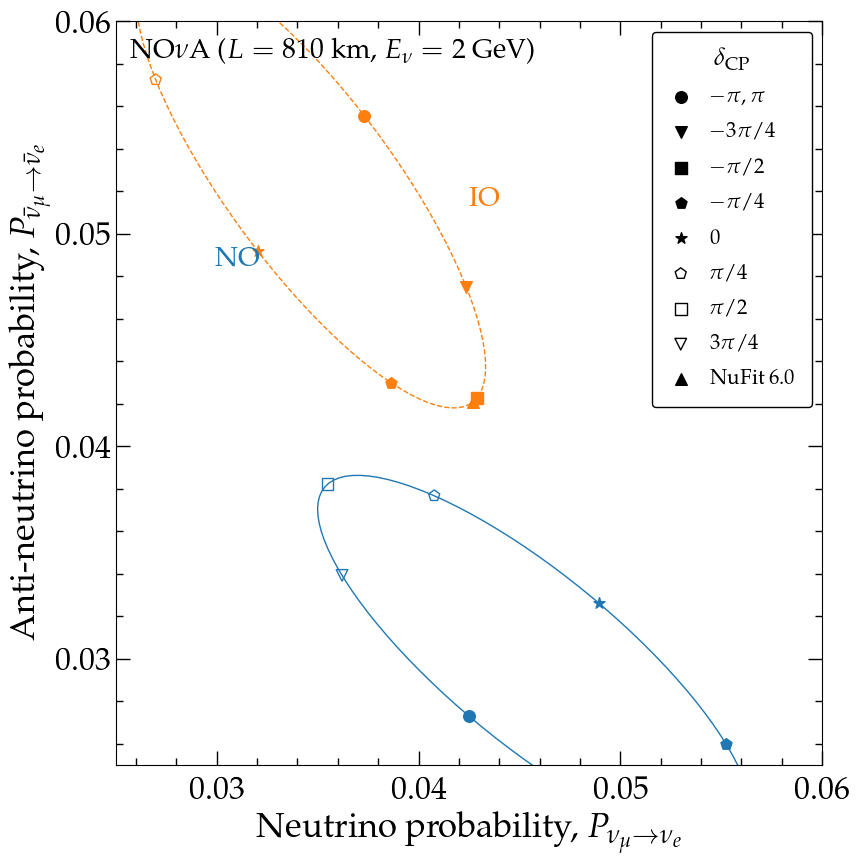

In [9]:
make_plot_biprobability([prob_nu_NO, prob_nu_IO], 
                        [prob_nubar_NO, prob_nubar_IO],
                        lc=['C0', 'C1'], ls=['-', '--'], lw=[1.0, 1.0],
                        points_sel_arr=[points_NO_sel, points_IO_sel],
                        label_prob_nu=r'Neutrino probability, $P_{\nu_\mu \to \nu_e}$', 
                        label_prob_nubar=r'Anti-neutrino probability, $P_{\bar{\nu}_\mu \to \bar{\nu}_e}$',
                        annotations=[
                            {'text': r'NO$\nu$A ($L = 810$~km, $E_\nu = 2$~GeV)', 'xy': (0.02,0.95), 'color': 'k', 'fontsize': 20, 
                             'ha': 'left'},
                            {'text': 'NO', 'xy': (0.14,0.67), 'color': 'C0', 'fontsize': 20, 'ha': 'left'},
                            {'text': 'IO', 'xy': (0.5,0.75), 'color': 'C1', 'fontsize': 20, 'ha': 'left'},
                        ], 
                        xaxis_major_locator=mpl.ticker.MultipleLocator(base=0.01),
                        xaxis_minor_locator=mpl.ticker.MultipleLocator(base=0.002),
                        yaxis_major_locator=mpl.ticker.MultipleLocator(base=0.01),
                        yaxis_minor_locator=mpl.ticker.MultipleLocator(base=0.002),
                        leg_fontsize=15, leg_loc='upper right', leg_ncol=1, xlim=[0.025,0.06], ylim=[0.025,0.06], save_fig=False)

In [10]:
# ====== T2K ======

# Pick the baseline and energy of T2K
baseline = 295 # [km]
energy = 0.6*gd.UNIT_GEV # [eV]

# Values of the delta_CP phase at which to compute the probabilities
dCP_npts = 100
dCP_arr = np.linspace(-np.pi, np.pi, dCP_npts)

# We will compute the appearance probabilities, i.e., nu_mu --> nu_e and nu_mu-bar --> nu_e-bar
nu_i, nu_f = gd.NUMU, gd.NUE

# Coherent matter potential in matter
rho = 3.0 # Average matter density in the Earth's crus [g cm^{-3}]
num_density_e = matter.num_density_e_func(l=0.0, density_matter_func=lambda l: rho, electron_fraction=0.5, density_matter_is_in_g_per_cm3=True) # Electron number density [eV^3]
VCC = matter.VCC_func(l=0.0, num_density_e_func=lambda l: num_density_e) # Coherent forward potential, VCC [eV]
# Note: we could have directly used VCC = gd.NUM_DENSITY_E_EARTH_CRUST

# Hamiltonian in matter
H_matt = hamiltonians.hamiltonian_3nu_matter(VCC)

# Hamiltonian for neutrinos (the matter potential is added)
def H_nu(s12, s23, s13, dCP, D21, D31):
    return hamiltonians.hamiltonian_3nu_vacuum(energy, s12, s23, s13, dCP, D21, D31, nubar=False, compute_matrix_multiplication=False) \
    + H_matt

# Hamiltonian for anti-neutrinos (the matter potential is subtracted)
def H_nubar(s12, s23, s13, dCP, D21, D31):
    return hamiltonians.hamiltonian_3nu_vacuum(energy, s12, s23, s13, dCP, D21, D31, nubar=True, compute_matrix_multiplication=False) \
    - H_matt

# Generate the neutrino and anti-neutrino oscillation probabilities for many different values of dCP
# osc_prob returns a 3x3 NumPy array with the probabilities: [[Pee, Pem, Pet], [Pme, Pmm, Pmt], [Pte, Ptm, Ptt]]
# nu_mu --> nu_e, normal ordering
prob_nu_NO = np.array([[dCP/np.pi, oscprob.osc_prob(lambda l: H_nu(s12_NO, s23_NO, s13_NO, dCP, D21_NO, D31_NO), 
                                                    0.0, baseline*gd.CONV_KM_TO_INV_EV, 
                                                    n_slabs=1, n_tpts_per_slab=2, magnus_exp_order=1,
                                                    integration_method='simpson', n_jobs=1)[nu_i][nu_f]] for dCP in dCP_arr])
# nu_mu-bar --> nu_e-bar, normal ordering
prob_nubar_NO = np.array([[dCP/np.pi, oscprob.osc_prob(lambda l: H_nubar(s12_NO, s23_NO, s13_NO, dCP, D21_NO, D31_NO),
                                                       0.0, baseline*gd.CONV_KM_TO_INV_EV, 
                                                       n_slabs=1, n_tpts_per_slab=2, magnus_exp_order=1,
                                                       integration_method='simpson', n_jobs=1)[nu_i][nu_f]] for dCP in dCP_arr])
# nu_mu --> nu_e, inverted ordering
prob_nu_IO = np.array([[dCP/np.pi, oscprob.osc_prob(lambda l: H_nu(s12_IO, s23_IO, s13_IO, dCP, D21_IO, D31_IO), 
                                                    0.0, baseline*gd.CONV_KM_TO_INV_EV, 
                                                    n_slabs=1, n_tpts_per_slab=2, magnus_exp_order=1,
                                                    integration_method='simpson', n_jobs=1)[nu_i][nu_f]] for dCP in dCP_arr])
# nu_mu-bar --> nu_e-bar, inverted ordering
prob_nubar_IO = np.array([[dCP/np.pi, oscprob.osc_prob(lambda l: H_nubar(s12_IO, s23_IO, s13_IO, dCP, D21_IO, D31_IO),
                                                       0.0, baseline*gd.CONV_KM_TO_INV_EV, 
                                                       n_slabs=1, n_tpts_per_slab=2, magnus_exp_order=1,
                                                       integration_method='simpson', n_jobs=1)[nu_i][nu_f]] for dCP in dCP_arr])

# Points for selected values of dCP
dCP_sel = [-np.pi, -0.75*np.pi, -0.5*np.pi, -0.25*np.pi, 0, 0.25*np.pi, 0.5*np.pi, 0.75*np.pi]
dCP_label_sel = [r'$-\pi, \pi$', r'$-3\pi/4$', r'$-\pi/2$', r'$-\pi/4$', r'$0$', r'$\pi/4$', r'$\pi/2$', r'$3\pi/4$', 'NuFit 6.0']
markers = ['o', 'v', 's', 'p', '*', 'p', 's', 'v', '^']
filled = [True, True, True, True, True, False, False, False, True]
prob_nu_NO_sel = np.array([[dCP/np.pi, oscprob.osc_prob(lambda l: H_nu(s12_NO, s23_NO, s13_NO, dCP, D21_NO, D31_NO), 
                                                        0.0, baseline*gd.CONV_KM_TO_INV_EV, 
                                                        n_slabs=1, n_tpts_per_slab=2, magnus_exp_order=1,
                                                        integration_method='simpson', n_jobs=1)[nu_i][nu_f]] 
                           for dCP in dCP_sel+[gd.DCP_NO_BF_NUFIT_6_0]])
prob_nubar_NO_sel = np.array([[dCP/np.pi, oscprob.osc_prob(lambda l: H_nubar(s12_NO, s23_NO, s13_NO, dCP, D21_NO, D31_NO), 
                                                           0.0, baseline*gd.CONV_KM_TO_INV_EV, 
                                                           n_slabs=1, n_tpts_per_slab=2, magnus_exp_order=1,
                                                           integration_method='simpson', n_jobs=1)[nu_i][nu_f]]
                              for dCP in dCP_sel+[gd.DCP_NO_BF_NUFIT_6_0]])
prob_nu_IO_sel = np.array([[dCP/np.pi, oscprob.osc_prob(lambda l: H_nu(s12_IO, s23_IO, s13_IO, dCP, D21_IO, D31_IO), 
                                                        0.0, baseline*gd.CONV_KM_TO_INV_EV, 
                                                        n_slabs=1, n_tpts_per_slab=2, magnus_exp_order=1,
                                                        integration_method='simpson', n_jobs=1)[nu_i][nu_f]]
                           for dCP in dCP_sel+[gd.DCP_IO_BF_NUFIT_6_0]])
prob_nubar_IO_sel = np.array([[dCP/np.pi, oscprob.osc_prob(lambda l: H_nubar(s12_IO, s23_IO, s13_IO, dCP, D21_IO, D31_IO), 
                                                           0.0, baseline*gd.CONV_KM_TO_INV_EV, 
                                                           n_slabs=1, n_tpts_per_slab=2, magnus_exp_order=1,
                                                           integration_method='simpson', n_jobs=1)[nu_i][nu_f]]
                              for dCP in dCP_sel+[gd.DCP_IO_BF_NUFIT_6_0]])
points_NO_sel = [[dCP_label_sel[i], markers[i], filled[i], [prob_nu_NO_sel[i][1], prob_nubar_NO_sel[i][1]]] for i in range(len(dCP_sel)+1)]
points_IO_sel = [[dCP_label_sel[i], markers[i], filled[i], [prob_nu_IO_sel[i][1], prob_nubar_IO_sel[i][1]]] for i in range(len(dCP_sel)+1)]

(<Figure size 900x900 with 1 Axes>,
 <Axes: xlabel='Neutrino probability, $P_{\\nu_\\mu \\to \\nu_e}$', ylabel='Anti-neutrino probability, $P_{\\bar{\\nu}_\\mu \\to \\bar{\\nu}_e}$'>)

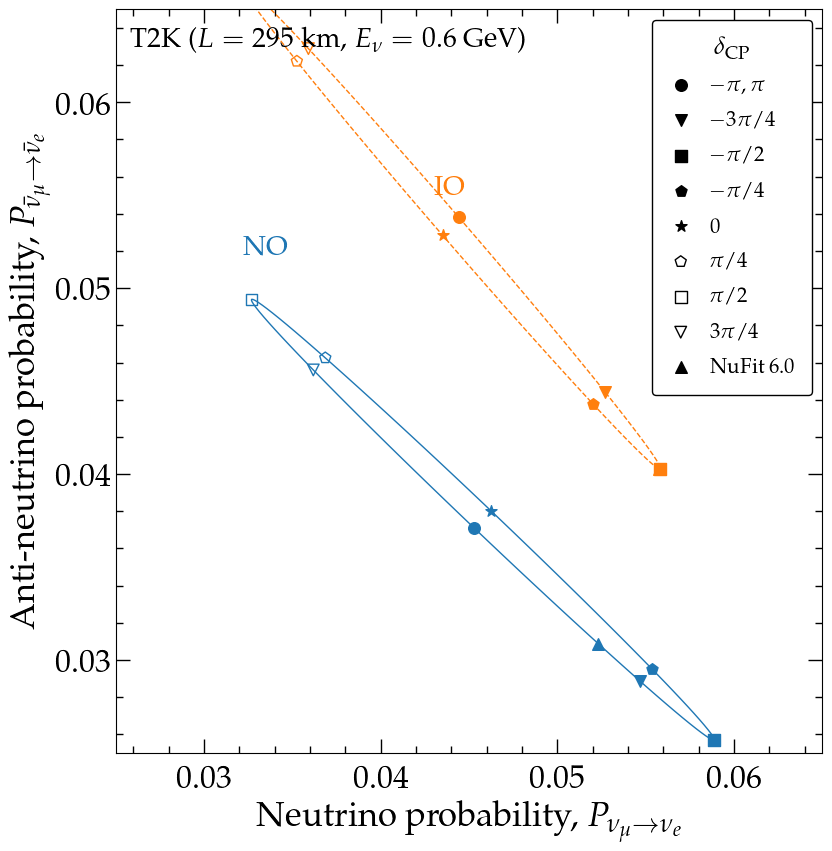

In [11]:
make_plot_biprobability([prob_nu_NO, prob_nu_IO], 
                        [prob_nubar_NO, prob_nubar_IO],
                        lc=['C0', 'C1'], ls=['-', '--'], lw=[1.0, 1.0],
                        points_sel_arr=[points_NO_sel, points_IO_sel],
                        label_prob_nu=r'Neutrino probability, $P_{\nu_\mu \to \nu_e}$', 
                        label_prob_nubar=r'Anti-neutrino probability, $P_{\bar{\nu}_\mu \to \bar{\nu}_e}$',
                        annotations=[
                            {'text': r'T2K ($L = 295$~km, $E_\nu = 0.6$~GeV)', 'xy': (0.02,0.95), 'color': 'k', 'fontsize': 20, 
                             'ha': 'left'},
                            {'text': 'NO', 'xy': (0.18,0.67), 'color': 'C0', 'fontsize': 20, 'ha': 'left'},
                            {'text': 'IO', 'xy': (0.45,0.75), 'color': 'C1', 'fontsize': 20, 'ha': 'left'},
                        ], 
                        xaxis_major_locator=mpl.ticker.MultipleLocator(base=0.01),
                        xaxis_minor_locator=mpl.ticker.MultipleLocator(base=0.002),
                        yaxis_major_locator=mpl.ticker.MultipleLocator(base=0.01),
                        yaxis_minor_locator=mpl.ticker.MultipleLocator(base=0.002),
                        leg_fontsize=15, leg_loc='upper right', leg_ncol=1, xlim=[0.025,0.065], ylim=[0.025,0.065], save_fig=False)

In [12]:
# ====== DUNE ======

# Pick the baseline and energy of DUNE
baseline = 1300 # [km]
energy = 2*gd.UNIT_GEV # [eV]

# Values of the delta_CP phase at which to compute the probabilities
dCP_npts = 100
dCP_arr = np.linspace(-np.pi, np.pi, dCP_npts)

# We will compute the appearance probabilities, i.e., nu_mu --> nu_e and nu_mu-bar --> nu_e-bar
nu_i, nu_f = gd.NUMU, gd.NUE

# Coherent matter potential in matter
rho = 3.0 # Average matter density in the Earth's crus [g cm^{-3}]
num_density_e = matter.num_density_e_func(l=0.0, density_matter_func=lambda l: rho, electron_fraction=0.5, density_matter_is_in_g_per_cm3=True) # Electron number density [eV^3]
VCC = matter.VCC_func(l=0.0, num_density_e_func=lambda l: num_density_e) # Coherent forward potential, VCC [eV]
# Note: we could have directly used VCC = gd.NUM_DENSITY_E_EARTH_CRUST

# Hamiltonian in matter
H_matt = hamiltonians.hamiltonian_3nu_matter(VCC)

# Hamiltonian for neutrinos (the matter potential is added)
def H_nu(s12, s23, s13, dCP, D21, D31):
    return hamiltonians.hamiltonian_3nu_vacuum(energy, s12, s23, s13, dCP, D21, D31, nubar=False, compute_matrix_multiplication=False) \
    + H_matt

# Hamiltonian for anti-neutrinos (the matter potential is subtracted)
def H_nubar(s12, s23, s13, dCP, D21, D31):
    return hamiltonians.hamiltonian_3nu_vacuum(energy, s12, s23, s13, dCP, D21, D31, nubar=True, compute_matrix_multiplication=False) \
    - H_matt

# Generate the neutrino and anti-neutrino oscillation probabilities for many different values of dCP
# osc_prob returns a 3x3 NumPy array with the probabilities: [[Pee, Pem, Pet], [Pme, Pmm, Pmt], [Pte, Ptm, Ptt]]
# nu_mu --> nu_e, normal ordering
prob_nu_NO = np.array([[dCP/np.pi, oscprob.osc_prob(lambda l: H_nu(s12_NO, s23_NO, s13_NO, dCP, D21_NO, D31_NO), 
                                                    0.0, baseline*gd.CONV_KM_TO_INV_EV, 
                                                    n_slabs=1, n_tpts_per_slab=2, magnus_exp_order=1,
                                                    integration_method='simpson', n_jobs=1)[nu_i][nu_f]] for dCP in dCP_arr])
# nu_mu-bar --> nu_e-bar, normal ordering
prob_nubar_NO = np.array([[dCP/np.pi, oscprob.osc_prob(lambda l: H_nubar(s12_NO, s23_NO, s13_NO, dCP, D21_NO, D31_NO),
                                                       0.0, baseline*gd.CONV_KM_TO_INV_EV, 
                                                       n_slabs=1, n_tpts_per_slab=2, magnus_exp_order=1,
                                                       integration_method='simpson', n_jobs=1)[nu_i][nu_f]] for dCP in dCP_arr])
# nu_mu --> nu_e, inverted ordering
prob_nu_IO = np.array([[dCP/np.pi, oscprob.osc_prob(lambda l: H_nu(s12_IO, s23_IO, s13_IO, dCP, D21_IO, D31_IO), 
                                                    0.0, baseline*gd.CONV_KM_TO_INV_EV, 
                                                    n_slabs=1, n_tpts_per_slab=2, magnus_exp_order=1,
                                                    integration_method='simpson', n_jobs=1)[nu_i][nu_f]] for dCP in dCP_arr])
# nu_mu-bar --> nu_e-bar, inverted ordering
prob_nubar_IO = np.array([[dCP/np.pi, oscprob.osc_prob(lambda l: H_nubar(s12_IO, s23_IO, s13_IO, dCP, D21_IO, D31_IO),
                                                       0.0, baseline*gd.CONV_KM_TO_INV_EV, 
                                                       n_slabs=1, n_tpts_per_slab=2, magnus_exp_order=1,
                                                       integration_method='simpson', n_jobs=1)[nu_i][nu_f]] for dCP in dCP_arr])

# Points for selected values of dCP
dCP_sel = [-np.pi, -0.75*np.pi, -0.5*np.pi, -0.25*np.pi, 0, 0.25*np.pi, 0.5*np.pi, 0.75*np.pi]
dCP_label_sel = [r'$-\pi, \pi$', r'$-3\pi/4$', r'$-\pi/2$', r'$-\pi/4$', r'$0$', r'$\pi/4$', r'$\pi/2$', r'$3\pi/4$', 'NuFit 6.0']
markers = ['o', 'v', 's', 'p', '*', 'p', 's', 'v', '^']
filled = [True, True, True, True, True, False, False, False, True]
prob_nu_NO_sel = np.array([[dCP/np.pi, oscprob.osc_prob(lambda l: H_nu(s12_NO, s23_NO, s13_NO, dCP, D21_NO, D31_NO), 
                                                        0.0, baseline*gd.CONV_KM_TO_INV_EV, 
                                                        n_slabs=1, n_tpts_per_slab=2, magnus_exp_order=1,
                                                        integration_method='simpson', n_jobs=1)[nu_i][nu_f]] 
                           for dCP in dCP_sel+[gd.DCP_NO_BF_NUFIT_6_0]])
prob_nubar_NO_sel = np.array([[dCP/np.pi, oscprob.osc_prob(lambda l: H_nubar(s12_NO, s23_NO, s13_NO, dCP, D21_NO, D31_NO), 
                                                           0.0, baseline*gd.CONV_KM_TO_INV_EV, 
                                                           n_slabs=1, n_tpts_per_slab=2, magnus_exp_order=1,
                                                           integration_method='simpson', n_jobs=1)[nu_i][nu_f]]
                              for dCP in dCP_sel+[gd.DCP_NO_BF_NUFIT_6_0]])
prob_nu_IO_sel = np.array([[dCP/np.pi, oscprob.osc_prob(lambda l: H_nu(s12_IO, s23_IO, s13_IO, dCP, D21_IO, D31_IO), 
                                                        0.0, baseline*gd.CONV_KM_TO_INV_EV, 
                                                        n_slabs=1, n_tpts_per_slab=2, magnus_exp_order=1,
                                                        integration_method='simpson', n_jobs=1)[nu_i][nu_f]]
                           for dCP in dCP_sel+[gd.DCP_IO_BF_NUFIT_6_0]])
prob_nubar_IO_sel = np.array([[dCP/np.pi, oscprob.osc_prob(lambda l: H_nubar(s12_IO, s23_IO, s13_IO, dCP, D21_IO, D31_IO), 
                                                           0.0, baseline*gd.CONV_KM_TO_INV_EV, 
                                                           n_slabs=1, n_tpts_per_slab=2, magnus_exp_order=1,
                                                           integration_method='simpson', n_jobs=1)[nu_i][nu_f]]
                              for dCP in dCP_sel+[gd.DCP_IO_BF_NUFIT_6_0]])
points_NO_sel = [[dCP_label_sel[i], markers[i], filled[i], [prob_nu_NO_sel[i][1], prob_nubar_NO_sel[i][1]]] for i in range(len(dCP_sel)+1)]
points_IO_sel = [[dCP_label_sel[i], markers[i], filled[i], [prob_nu_IO_sel[i][1], prob_nubar_IO_sel[i][1]]] for i in range(len(dCP_sel)+1)]

(<Figure size 900x900 with 1 Axes>,
 <Axes: xlabel='Neutrino probability, $P_{\\nu_\\mu \\to \\nu_e}$', ylabel='Anti-neutrino probability, $P_{\\bar{\\nu}_\\mu \\to \\bar{\\nu}_e}$'>)

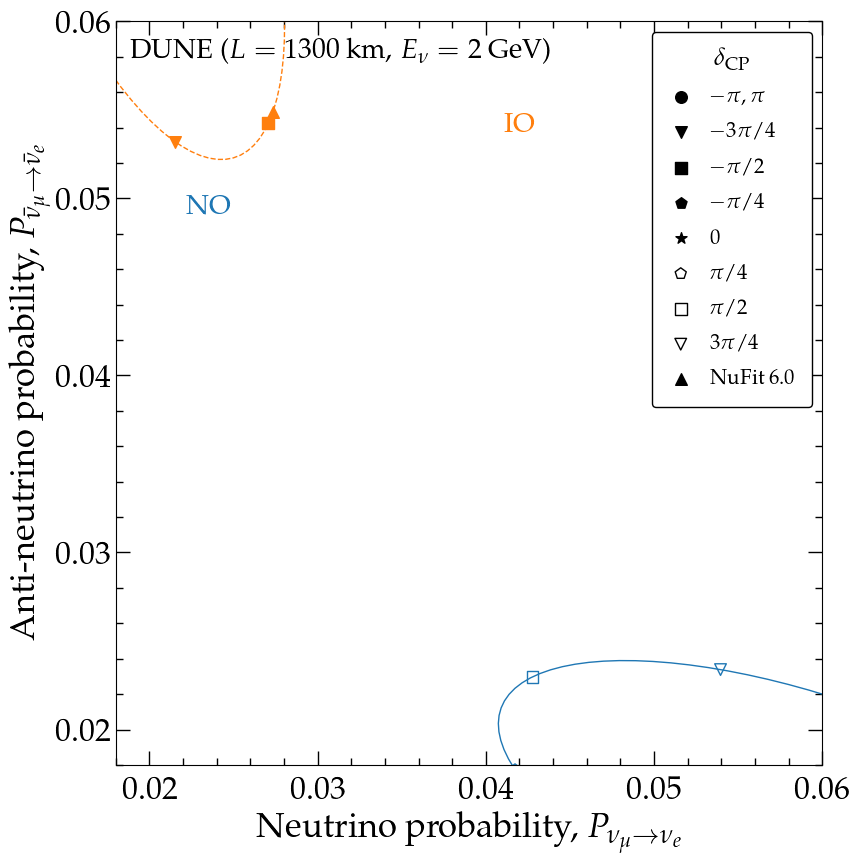

In [13]:
make_plot_biprobability([prob_nu_NO, prob_nu_IO], 
                        [prob_nubar_NO, prob_nubar_IO],
                        lc=['C0', 'C1'], ls=['-', '--'], lw=[1.0, 1.0],
                        points_sel_arr=[points_NO_sel, points_IO_sel],
                        label_prob_nu=r'Neutrino probability, $P_{\nu_\mu \to \nu_e}$', 
                        label_prob_nubar=r'Anti-neutrino probability, $P_{\bar{\nu}_\mu \to \bar{\nu}_e}$',
                        annotations=[
                            {'text': r'DUNE ($L = 1300$~km, $E_\nu = 2$~GeV)', 'xy': (0.02,0.95), 'color': 'k', 'fontsize': 20, 
                             'ha': 'left'},
                            {'text': 'NO', 'xy': (0.10,0.74), 'color': 'C0', 'fontsize': 20, 'ha': 'left'},
                            {'text': 'IO', 'xy': (0.55,0.85), 'color': 'C1', 'fontsize': 20, 'ha': 'left'},
                        ], 
                        xaxis_major_locator=mpl.ticker.MultipleLocator(base=0.01),
                        xaxis_minor_locator=mpl.ticker.MultipleLocator(base=0.002),
                        yaxis_major_locator=mpl.ticker.MultipleLocator(base=0.01),
                        yaxis_minor_locator=mpl.ticker.MultipleLocator(base=0.002),
                        leg_fontsize=15, leg_loc='upper right', leg_ncol=1, xlim=[0.018,0.06], ylim=[0.018,0.06], save_fig=False)

## In matter, through the Earth (varying density, PREM)

We send a neutrino beam from Fermilab through the Earth to SNOLAB, Homestake, CERN, and the South Pole, using the onion-like matter density profile of the Preliminary Reference Earth Model (PREM).  For more details, including the line-of-sight density profiles in each of these cases, see the notebook `04_magnus_long_baseline.ipynb`.  

For this example, we fix the mass ordering to normal.

In [14]:
# Electron number density inside Earth, using the PREM density model
def num_density_e_func_prem(r): 
    return matter.num_density_e_func(r, earth.density_matter_func_prem, electron_fraction=0.5, density_matter_is_in_g_per_cm3=True) # [eV^{-3}]

# Coherent forward potential inside Earth, using the PREM density model
def VCC_func_prem(r):
    return matter.VCC_func(r, num_density_e_func_prem) # [eV]

# Hamiltonian for neutrinos (the matter potential is added)
def H_nu(costhz, l, energy, s12, s23, s13, dCP, D21, D31):
    # Given a direction (costhz) and a depth (l), compute the radial distance from the center of the Earth (r)
    r = earth.earth_radial_distance_from_depth(costhz, l/gd.CONV_KM_TO_INV_EV) # [km]
    return hamiltonians.hamiltonian_3nu_vacuum(energy, s12, s23, s13, dCP, D21, D31, nubar=False) \
    + hamiltonians.hamiltonian_3nu_matter(VCC_func_prem(r))

# Hamiltonian for anti-neutrinos (the matter potential is subtracted)
def H_nubar(costhz, l, energy, s12, s23, s13, dCP, D21, D31):
    r = earth.earth_radial_distance_from_depth(costhz, l/gd.CONV_KM_TO_INV_EV) # [km]
    return hamiltonians.hamiltonian_3nu_vacuum(energy, s12, s23, s13, dCP, D21, D31, nubar=True) \
    - hamiltonians.hamiltonian_3nu_matter(VCC_func_prem(r))

# Cosines of zenith angles of Fermilab measured from the detector locations (we would get the same result if we seapped them, since we
# consider that Earth is radially symmetric)
detectors = ['SNOLAB', 'Homestake', 'CERN', "South Pole"]
costhz_arr = [earth.costhz_between_points_on_surface(earth.loc_coords_dms[det.lower().replace(" ", "_")]['lat'], 
                                                     earth.loc_coords_dms[det.lower().replace(" ", "_")]['lon'],
                                                     earth.loc_coords_dms['fermilab']['lat'], 
                                                     earth.loc_coords_dms['fermilab']['lon']) 
             for det in detectors]

# Maximum baselines inside the Earth
l_max_arr = [earth.distance_traveled_inside_earth(costhz) for costhz in costhz_arr] # [km]

In [15]:
# Neutrino energy
energy = 2*gd.UNIT_GEV # [eV]

# Values of the delta_CP phase at which to compute the probabilities
dCP_npts = 100
dCP_arr = np.linspace(-np.pi, np.pi, dCP_npts)

# We will compute the appearance probabilities, i.e., nu_mu --> nu_e and nu_mu-bar --> nu_e-bar
nu_i, nu_f = gd.NUMU, gd.NUE

# Points for selected values of dCP
dCP_sel = [-np.pi, -0.75*np.pi, -0.5*np.pi, -0.25*np.pi, 0, 0.25*np.pi, 0.5*np.pi, 0.75*np.pi]
dCP_label_sel = [r'$-\pi, \pi$', r'$-3\pi/4$', r'$-\pi/2$', r'$-\pi/4$', r'$0$', r'$\pi/4$', r'$\pi/2$', r'$3\pi/4$', 'NuFit 6.0']
markers = ['o', 'v', 's', 'p', '*', 'p', 's', 'v', '^']
filled = [True, True, True, True, True, False, False, False, True]

# Below, we use n_slabs=100, n_tpts_per_slab=10, and magnus_exp_order=3, which would allow for the MSW resonance to be picked (say, around 
# 10 GeV), but for our choice of 2 GeV, far from the resonance, this is overkill 
prob_nu_arr, prob_nubar_arr, points_sel_arr = [], [], []
for i in range(len(detectors)):
    print("detector = " + detectors[i])
    # nu_mu --> nu_e
    prob_nu = np.array([[dCP/np.pi, oscprob.osc_prob(lambda l: H_nu(costhz_arr[i], l, energy, 
                                                                    s12_NO, s23_NO, s13_NO, dCP, D21_NO, D31_NO), 
                                                     0.0, l_max_arr[i]*gd.CONV_KM_TO_INV_EV, 
                                                     n_slabs=100, n_tpts_per_slab=10, magnus_exp_order=3, 
                                                     integration_method='simpson', n_jobs=10)[nu_i][nu_f]] for dCP in dCP_arr])
    # nu_mu-bar --> nu_e-bar
    prob_nubar = np.array([[dCP/np.pi, oscprob.osc_prob(lambda l: H_nubar(costhz_arr[i], l, energy, 
                                                                          s12_NO, s23_NO, s13_NO, dCP, D21_NO, D31_NO),
                                                        0.0, l_max_arr[i]*gd.CONV_KM_TO_INV_EV, 
                                                        n_slabs=100, n_tpts_per_slab=10, magnus_exp_order=3,
                                                        integration_method='simpson', n_jobs=10)[nu_i][nu_f]] for dCP in dCP_arr])
    prob_nu_arr.append(prob_nu)
    prob_nubar_arr.append(prob_nubar)
    # Compute selected points
    points_nu_sel, points_nubar_sel = [], []
    prob_nu_sel = np.array([[dCP/np.pi, oscprob.osc_prob(lambda l: H_nu(costhz_arr[i], l, energy, 
                                                                    s12_NO, s23_NO, s13_NO, dCP, D21_NO, D31_NO), 
                                                         0.0, l_max_arr[i]*gd.CONV_KM_TO_INV_EV, 
                                                         n_slabs=100, n_tpts_per_slab=10, magnus_exp_order=3,
                                                         integration_method='simpson', n_jobs=10)[nu_i][nu_f]] 
                               for dCP in dCP_sel+[gd.DCP_NO_BF_NUFIT_6_0]])
    prob_nubar_sel = np.array([[dCP/np.pi, oscprob.osc_prob(lambda l: H_nubar(costhz_arr[i], l, energy, 
                                                                              s12_NO, s23_NO, s13_NO, dCP, D21_NO, D31_NO), 
                                                            0.0, l_max_arr[i]*gd.CONV_KM_TO_INV_EV, 
                                                            n_slabs=100, n_tpts_per_slab=10, magnus_exp_order=3,
                                                            integration_method='simpson', n_jobs=10)[nu_i][nu_f]] 
                               for dCP in dCP_sel+[gd.DCP_NO_BF_NUFIT_6_0]])
    points_sel = [[dCP_label_sel[j], markers[j], filled[j], [prob_nu_sel[j][1], prob_nubar_sel[j][1]]] for j in range(len(dCP_sel)+1)]
    points_sel_arr.append(points_sel)

detector = SNOLAB


detector = Homestake


detector = CERN


detector = South Pole


(<Figure size 900x900 with 1 Axes>,
 <Axes: xlabel='Neutrino probability, $P_{\\nu_\\mu \\to \\nu_e}$', ylabel='Anti-neutrino probability, $P_{\\bar{\\nu}_\\mu \\to \\bar{\\nu}_e}$'>)

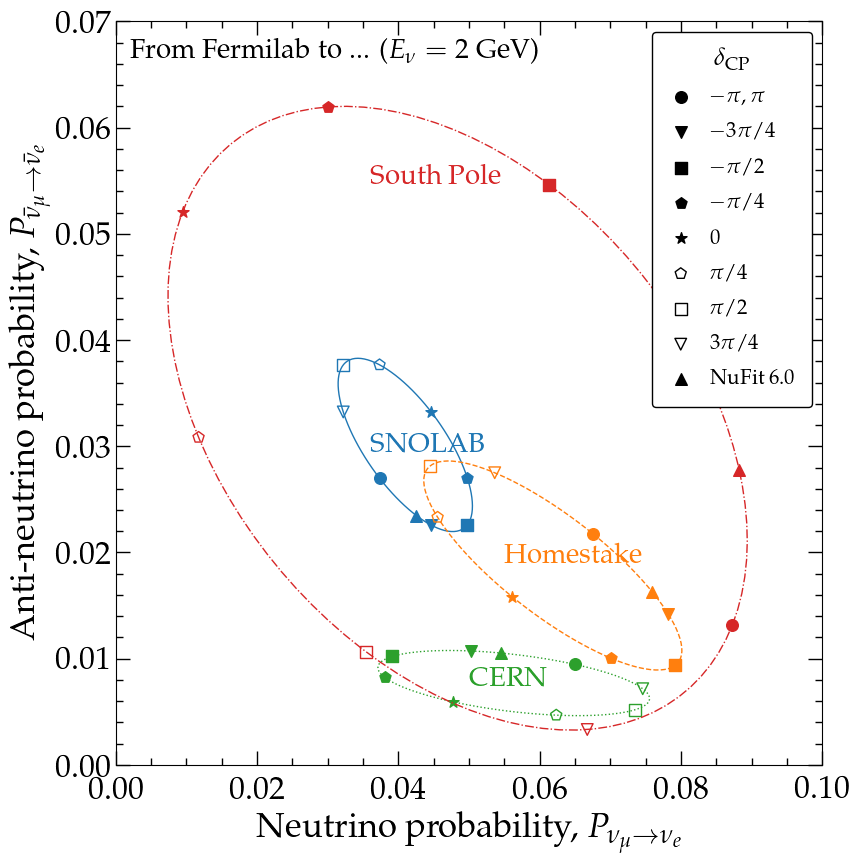

In [16]:
make_plot_biprobability(prob_nu_arr, prob_nubar_arr,
                        lc=['C0', 'C1', 'C2', 'C3'], ls=['-', '--', ':', '-.'], lw=[1.0, 1.0, 1.0, 1.0],
                        points_sel_arr=points_sel_arr,
                        label_prob_nu=r'Neutrino probability, $P_{\nu_\mu \to \nu_e}$', 
                        label_prob_nubar=r'Anti-neutrino probability, $P_{\bar{\nu}_\mu \to \bar{\nu}_e}$',
                        annotations=[
                            {'text': r'From Fermilab to ... ($E_\nu = 2$~GeV)', 'xy': (0.02,0.95), 'color': 'k', 'fontsize': 20, 
                             'ha': 'left'},
                            {'text': 'SNOLAB', 'xy': (0.36,0.42), 'color': 'C0', 'fontsize': 20, 'ha': 'left'},
                            {'text': 'Homestake', 'xy': (0.55,0.27), 'color': 'C1', 'fontsize': 20, 'ha': 'left'},
                            {'text': 'CERN', 'xy': (0.50,0.105), 'color': 'C2', 'fontsize': 20, 'ha': 'left'},
                            {'text': 'South Pole', 'xy': (0.36,0.78), 'color': 'C3', 'fontsize': 20, 'ha': 'left'}
                        ], 
                        xaxis_major_locator=mpl.ticker.MultipleLocator(base=0.02),
                        xaxis_minor_locator=mpl.ticker.MultipleLocator(base=0.005),
                        yaxis_major_locator=mpl.ticker.MultipleLocator(base=0.01),
                        yaxis_minor_locator=mpl.ticker.MultipleLocator(base=0.002),
                        leg_fontsize=15, leg_loc='upper right', leg_ncol=1, xlim=[0,0.10], ylim=[0,0.07], save_fig=False)

In the plot above, we used 2 GeV, which, for the source-detector configurations we explore, is far from the MSW resonance energy inside Earth, so the high-order Magnus expansion was not really needed.

Below, we repeat the for a higher energy, closer to the MSW resonance.  Therefore, the higher-order Magnus expansion and high number of slabs (`n_slabs = 100`) is, in general, needed in order to be sure to pick up any resonance.  The recommendation is to always use higher-order expansion in order to be sure to pick up any resonance, which is especially important when adding new-physics effects, for which, in general, we may not know a priori at what energy the resonance occurs.  (Of course, the energy at which the resonance happens depends on the directiomn of neutrino propagation, so for a fixed energy, we typically cannot hit the resonance for all source-detector configurations simultaneously.)

In [17]:
# Neutrino energy
energy = 20*gd.UNIT_GEV # [eV]

# Below, we use n_labs=100, n_tpts_per_slab=10, and magnus_exp_order=3, which would allow for the MSW resonance to be picked (say, around 
# 10 GeV), but for our choice of 2 GeV, far from the resonance, this is overkill 
prob_nu_arr, prob_nubar_arr, points_sel_arr = [], [], []
for i in range(len(detectors)):
    print("detector = " + detectors[i])
    # nu_mu --> nu_e
    prob_nu = np.array([[dCP/np.pi, oscprob.osc_prob(lambda l: H_nu(costhz_arr[i], l, energy, 
                                                                    s12_NO, s23_NO, s13_NO, dCP, D21_NO, D31_NO), 
                                                     0.0, l_max_arr[i]*gd.CONV_KM_TO_INV_EV, 
                                                     n_slabs=100, n_tpts_per_slab=10, magnus_exp_order=3, 
                                                     integration_method='simpson', n_jobs=10)[nu_i][nu_f]] for dCP in dCP_arr])
    # nu_mu-bar --> nu_e-bar
    prob_nubar = np.array([[dCP/np.pi, oscprob.osc_prob(lambda l: H_nubar(costhz_arr[i], l, energy, 
                                                                          s12_NO, s23_NO, s13_NO, dCP, D21_NO, D31_NO),
                                                        0.0, l_max_arr[i]*gd.CONV_KM_TO_INV_EV, 
                                                        n_slabs=100, n_tpts_per_slab=10, magnus_exp_order=3,
                                                        integration_method='simpson', n_jobs=10)[nu_i][nu_f]] for dCP in dCP_arr])
    prob_nu_arr.append(prob_nu)
    prob_nubar_arr.append(prob_nubar)
    # Compute selected points
    points_nu_sel, points_nubar_sel = [], []
    prob_nu_sel = np.array([[dCP/np.pi, oscprob.osc_prob(lambda l: H_nu(costhz_arr[i], l, energy, 
                                                                    s12_NO, s23_NO, s13_NO, dCP, D21_NO, D31_NO), 
                                                         0.0, l_max_arr[i]*gd.CONV_KM_TO_INV_EV, 
                                                         n_slabs=100, n_tpts_per_slab=10, magnus_exp_order=3,
                                                         integration_method='simpson', n_jobs=10)[nu_i][nu_f]] 
                               for dCP in dCP_sel+[gd.DCP_NO_BF_NUFIT_6_0]])
    prob_nubar_sel = np.array([[dCP/np.pi, oscprob.osc_prob(lambda l: H_nubar(costhz_arr[i], l, energy, 
                                                                              s12_NO, s23_NO, s13_NO, dCP, D21_NO, D31_NO), 
                                                            0.0, l_max_arr[i]*gd.CONV_KM_TO_INV_EV, 
                                                            n_slabs=100, n_tpts_per_slab=10, magnus_exp_order=3,
                                                            integration_method='simpson', n_jobs=10)[nu_i][nu_f]] 
                               for dCP in dCP_sel+[gd.DCP_NO_BF_NUFIT_6_0]])
    points_sel = [[dCP_label_sel[j], markers[j], filled[j], [prob_nu_sel[j][1], prob_nubar_sel[j][1]]] for j in range(len(dCP_sel)+1)]
    points_sel_arr.append(points_sel)

detector = SNOLAB


detector = Homestake


detector = CERN


detector = South Pole


Locator attempting to generate 1003 ticks ([-0.001, ..., 1.0010000000000001]), which exceeds Locator.MAXTICKS (1000).


Locator attempting to generate 2003 ticks ([-0.0005, ..., 1.0005000000000002]), which exceeds Locator.MAXTICKS (1000).


Locator attempting to generate 10003 ticks ([-0.0001, ..., 1.0001]), which exceeds Locator.MAXTICKS (1000).


(<Figure size 900x900 with 1 Axes>,
 <Axes: xlabel='Neutrino probability, $P_{\\nu_\\mu \\to \\nu_e}$', ylabel='Anti-neutrino probability, $P_{\\bar{\\nu}_\\mu \\to \\bar{\\nu}_e}$'>)

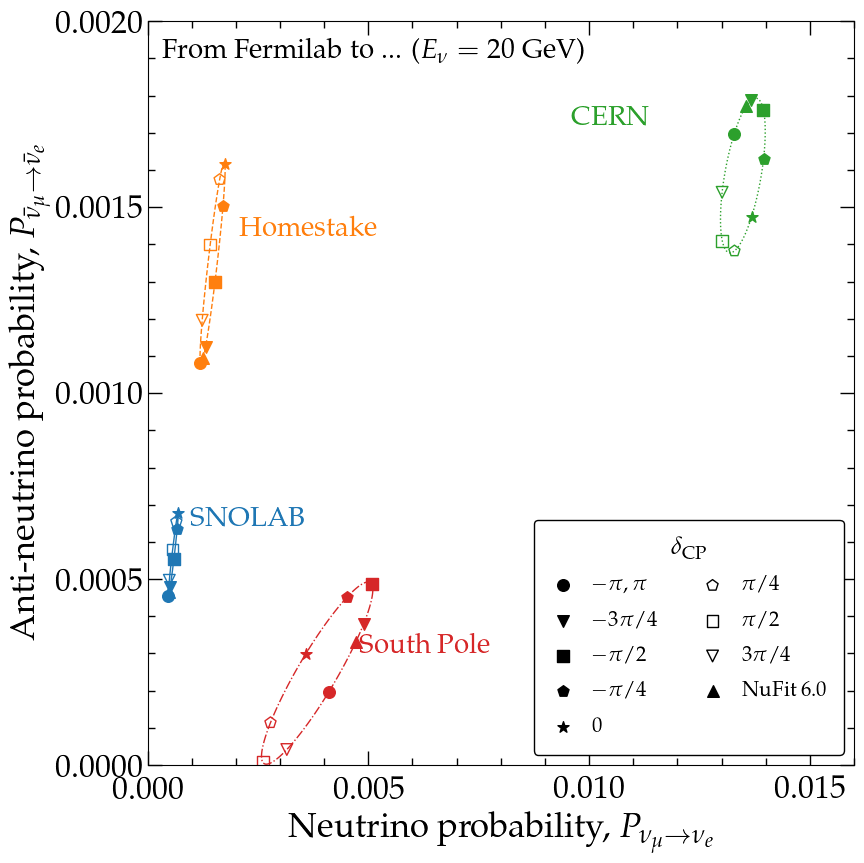

In [18]:
make_plot_biprobability(prob_nu_arr, prob_nubar_arr,
                        lc=['C0', 'C1', 'C2', 'C3'], ls=['-', '--', ':', '-.'], lw=[1.0, 1.0, 1.0, 1.0],
                        points_sel_arr=points_sel_arr,
                        label_prob_nu=r'Neutrino probability, $P_{\nu_\mu \to \nu_e}$', 
                        label_prob_nubar=r'Anti-neutrino probability, $P_{\bar{\nu}_\mu \to \bar{\nu}_e}$',
                        annotations=[
                            {'text': r'From Fermilab to ... ($E_\nu = 20$~GeV)', 'xy': (0.02,0.95), 'color': 'k', 'fontsize': 20, 
                             'ha': 'left'},
                            {'text': 'SNOLAB', 'xy': (0.06,0.32), 'color': 'C0', 'fontsize': 20, 'ha': 'left'},
                            {'text': 'Homestake', 'xy': (0.13,0.71), 'color': 'C1', 'fontsize': 20, 'ha': 'left'},
                            {'text': 'CERN', 'xy': (0.60,0.86), 'color': 'C2', 'fontsize': 20, 'ha': 'left'},
                            {'text': 'South Pole', 'xy': (0.30,0.15), 'color': 'C3', 'fontsize': 20, 'ha': 'left'}
                        ], 
                        xaxis_major_locator=mpl.ticker.MultipleLocator(base=0.005),
                        xaxis_minor_locator=mpl.ticker.MultipleLocator(base=0.001),
                        yaxis_major_locator=mpl.ticker.MultipleLocator(base=0.0005),
                        yaxis_minor_locator=mpl.ticker.MultipleLocator(base=0.0001),
                        leg_fontsize=15, leg_loc='lower right', leg_ncol=2, xlim=[0,0.016], ylim=[0,0.002], save_fig=False)

---

**Previous:** [Long baselines](04_magnus_long_baseline.ipynb)  
**Next:** [Oscillograms](06_magnus_oscillograms.ipynb) --- probability across zenith angle and energy at once  
[API reference](https://mbustama.github.io/Magnus/functions.html) &middot; [Implementation details](https://mbustama.github.io/Magnus/implementation_details.html) &middot; [All notebooks](.)